In [32]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


sns.set_theme(style="whitegrid")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [33]:
#import cleaned dataset
df = pd.read_csv('../data/processed/matches_1930_2022_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (964, 20)


,team_A,team_B,Date,Year,Host,Round,Venue,home_manager,away_manager,target,A_goals_scored_last_5,A_goals_conceded_last_5,A_win_rate_last_5,A_matches_played_total,B_goals_scored_last_5,B_goals_conceded_last_5,B_win_rate_last_5,B_matches_played_total,is_host_A,is_host_B
0,France,Mexico,1930-07-13,1930,Uruguay,Group stage,"Pocitos, Montevideo",Raoul Caudron,Juan Luque,0,0,0,0.0,0,0,0,0.0,0,0,0
1,United States,Belgium,1930-07-13,1930,Uruguay,Group stage,"Parque Central, Montevideo",Bob Millar,Hector Goetinck,0,0,0,0.0,0,0,0,0.0,0,0,0
2,Yugoslavia,Brazil,1930-07-14,1930,Uruguay,Group stage,"Parque Central, Montevideo",Bosko Simonovic,Pindaro De Carvalho,0,0,0,0.0,0,0,0,0.0,0,0,0
3,Romania,Peru,1930-07-14,1930,Uruguay,Group stage,"Pocitos, Montevideo",Octav Luchide,Francisco Bru,0,0,0,0.0,0,0,0,0.0,0,0,0
4,Argentina,France,1930-07-15,1930,Uruguay,Group stage,"Parque Central, Montevideo",Francisco Olazar,Raoul Caudron,0,0,0,0.0,0,4,1,1.0,1,0,0


In [34]:
# Prepare features and target for model training
# Target classes: 0 = Team A win, 1 = draw, 2 = Team B win.
# Extract the target before transforming the input columns.
y = df["target"].astype(int)
target_names = {0: "Team A win", 1: "Draw", 2: "Team B win"}

# Convert the date into numeric calendar features and remove the raw date.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["match_month"] = df["Date"].dt.month
df["match_day"] = df["Date"].dt.day

# Drop the target and raw date; one-hot encode remaining categorical features.
X = df.drop(columns=["target", "Date"])
categorical_cols = X.select_dtypes(include="object").columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Target distribution:")
print(y.map(target_names).value_counts().reindex(target_names.values()))
X.head()


Features shape: (964, 1104)
Target shape: (964,)
Target distribution:
target
Team A win    532
Draw          214
Team B win    218
Name: count, dtype: int64


,Year,A_goals_scored_last_5,A_goals_conceded_last_5,A_win_rate_last_5,A_matches_played_total,B_goals_scored_last_5,B_goals_conceded_last_5,B_win_rate_last_5,B_matches_played_total,is_host_A,...,away_manager_Winfried Schäfer,away_manager_Xavier Azkargorta Uriarte,away_manager_Yong Shik Kim,away_manager_Zeze Moreira,away_manager_Zico,away_manager_Zlatko Dalić,away_manager_Zlatko Kranjčar,away_manager_Åge Hareide,away_manager_Óscar Tabárez,away_manager_Şenol Güneş
0,1930,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1930,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1930,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1930,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1930,0,0,0.0,0,4,1,1.0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
# Split the data into training and test sets (80/20).
# Stratification preserves the proportions of the three match outcomes.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")
print(f"Training targets: {y_train.shape}")
print(f"Test targets: {y_test.shape}")

split_distribution = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True),
    "Training set": y_train.value_counts(normalize=True),
    "Test set": y_test.value_counts(normalize=True)
}).rename(index=target_names)
split_distribution.round(3)


Training features: (771, 1104)
Test features: (193, 1104)
Training targets: (771,)
Test targets: (193,)


,Full dataset,Training set,Test set
target,,,
Team A win,0.552,0.553,0.549
Team B win,0.226,0.226,0.228
Draw,0.222,0.222,0.223


In [36]:
# 1. Logistic Regression
from sklearn.pipeline import Pipeline

model_results = []

def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scores = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, predictions, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, predictions, average="weighted", zero_division=0)
    }
    model_results.append(scores)
    print(pd.Series({metric: scores[metric] for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]}).round(4))
    print("\nClassification report:")
    print(classification_report(y_test, predictions, target_names=list(target_names.values()), zero_division=0))
    return model

logistic_model = evaluate_model(
    Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))]),
    "Logistic Regression"
)


Accuracy     0.5026
Precision    0.4973
Recall       0.5026
F1 Score     0.4984
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.63      0.67      0.65       106
        Draw       0.24      0.26      0.25        43
  Team B win       0.43      0.34      0.38        44

    accuracy                           0.50       193
   macro avg       0.43      0.42      0.43       193
weighted avg       0.50      0.50      0.50       193



In [37]:
# 2. Decision Tree
decision_tree_model = evaluate_model(
    DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Decision Tree"
)


Accuracy     0.5803
Precision    0.5728
Recall       0.5803
F1 Score     0.5723
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.75      0.75      0.75       106
        Draw       0.31      0.21      0.25        43
  Team B win       0.41      0.55      0.47        44

    accuracy                           0.58       193
   macro avg       0.49      0.50      0.49       193
weighted avg       0.57      0.58      0.57       193



In [38]:
# 3. Random Forest
random_forest_model = evaluate_model(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Random Forest"
)


Accuracy     0.5699
Precision    0.4809
Recall       0.5699
F1 Score     0.4983
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.63      0.88      0.73       106
        Draw       0.20      0.02      0.04        43
  Team B win       0.40      0.36      0.38        44

    accuracy                           0.57       193
   macro avg       0.41      0.42      0.38       193
weighted avg       0.48      0.57      0.50       193



In [39]:
# 4. K-Nearest Neighbors (KNN)
knn_model = evaluate_model(
    Pipeline([("scaler", StandardScaler()),
              ("model", KNeighborsClassifier(n_neighbors=15))]),
    "K-Nearest Neighbors"
)


Accuracy     0.5389
Precision    0.3006
Recall       0.5389
F1 Score     0.3859
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.55      0.98      0.70       106
        Draw       0.00      0.00      0.00        43
  Team B win       0.00      0.00      0.00        44

    accuracy                           0.54       193
   macro avg       0.18      0.33      0.23       193
weighted avg       0.30      0.54      0.39       193



In [ ]:
# 5. Support Vector Machine (SVM)
svm_model = evaluate_model(
    Pipeline([("scaler", StandardScaler()),
              ("model", SVC(class_weight="balanced", random_state=42))]),
    "Support Vector Machine"
)


In [ ]:
# 6. Gradient Boosting
gradient_boosting_model = evaluate_model(
    GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42),
    "Gradient Boosting"
)


Accuracy     0.5959
Precision    0.5469
Recall       0.5959
F1 Score     0.5401
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.65      0.86      0.74       106
        Draw       0.38      0.07      0.12        43
  Team B win       0.47      0.48      0.47        44

    accuracy                           0.60       193
   macro avg       0.50      0.47      0.44       193
weighted avg       0.55      0.60      0.54       193



In [ ]:
# 7. Naive Bayes
naive_bayes_model = evaluate_model(
    GaussianNB(),
    "Naive Bayes"
)


Accuracy     0.4663
Precision    0.4883
Recall       0.4663
F1 Score     0.4736
dtype: float64

Classification report:
              precision    recall  f1-score   support

  Team A win       0.64      0.55      0.59       106
        Draw       0.25      0.26      0.25        43
  Team B win       0.36      0.48      0.41        44

    accuracy                           0.47       193
   macro avg       0.42      0.43      0.42       193
weighted avg       0.49      0.47      0.47       193



In [ ]:
# Compare all models
comparison = (pd.DataFrame(model_results)
              .set_index("Model")
              .sort_values("F1 Score", ascending=False))
comparison[["Accuracy", "Precision", "Recall", "F1 Score"]].round(4)


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Gradient Boosting,0.5959,0.5469,0.5959,0.5401
Random Forest,0.5699,0.5061,0.5699,0.4951
Logistic Regression,0.5026,0.4930,0.5026,0.4945
Support Vector Machine,0.5026,0.4724,0.5026,0.4837
Decision Tree,0.4611,0.5288,0.4611,0.4799
Naive Bayes,0.4663,0.4883,0.4663,0.4736
K-Nearest Neighbors,0.5440,0.4494,0.5440,0.4042


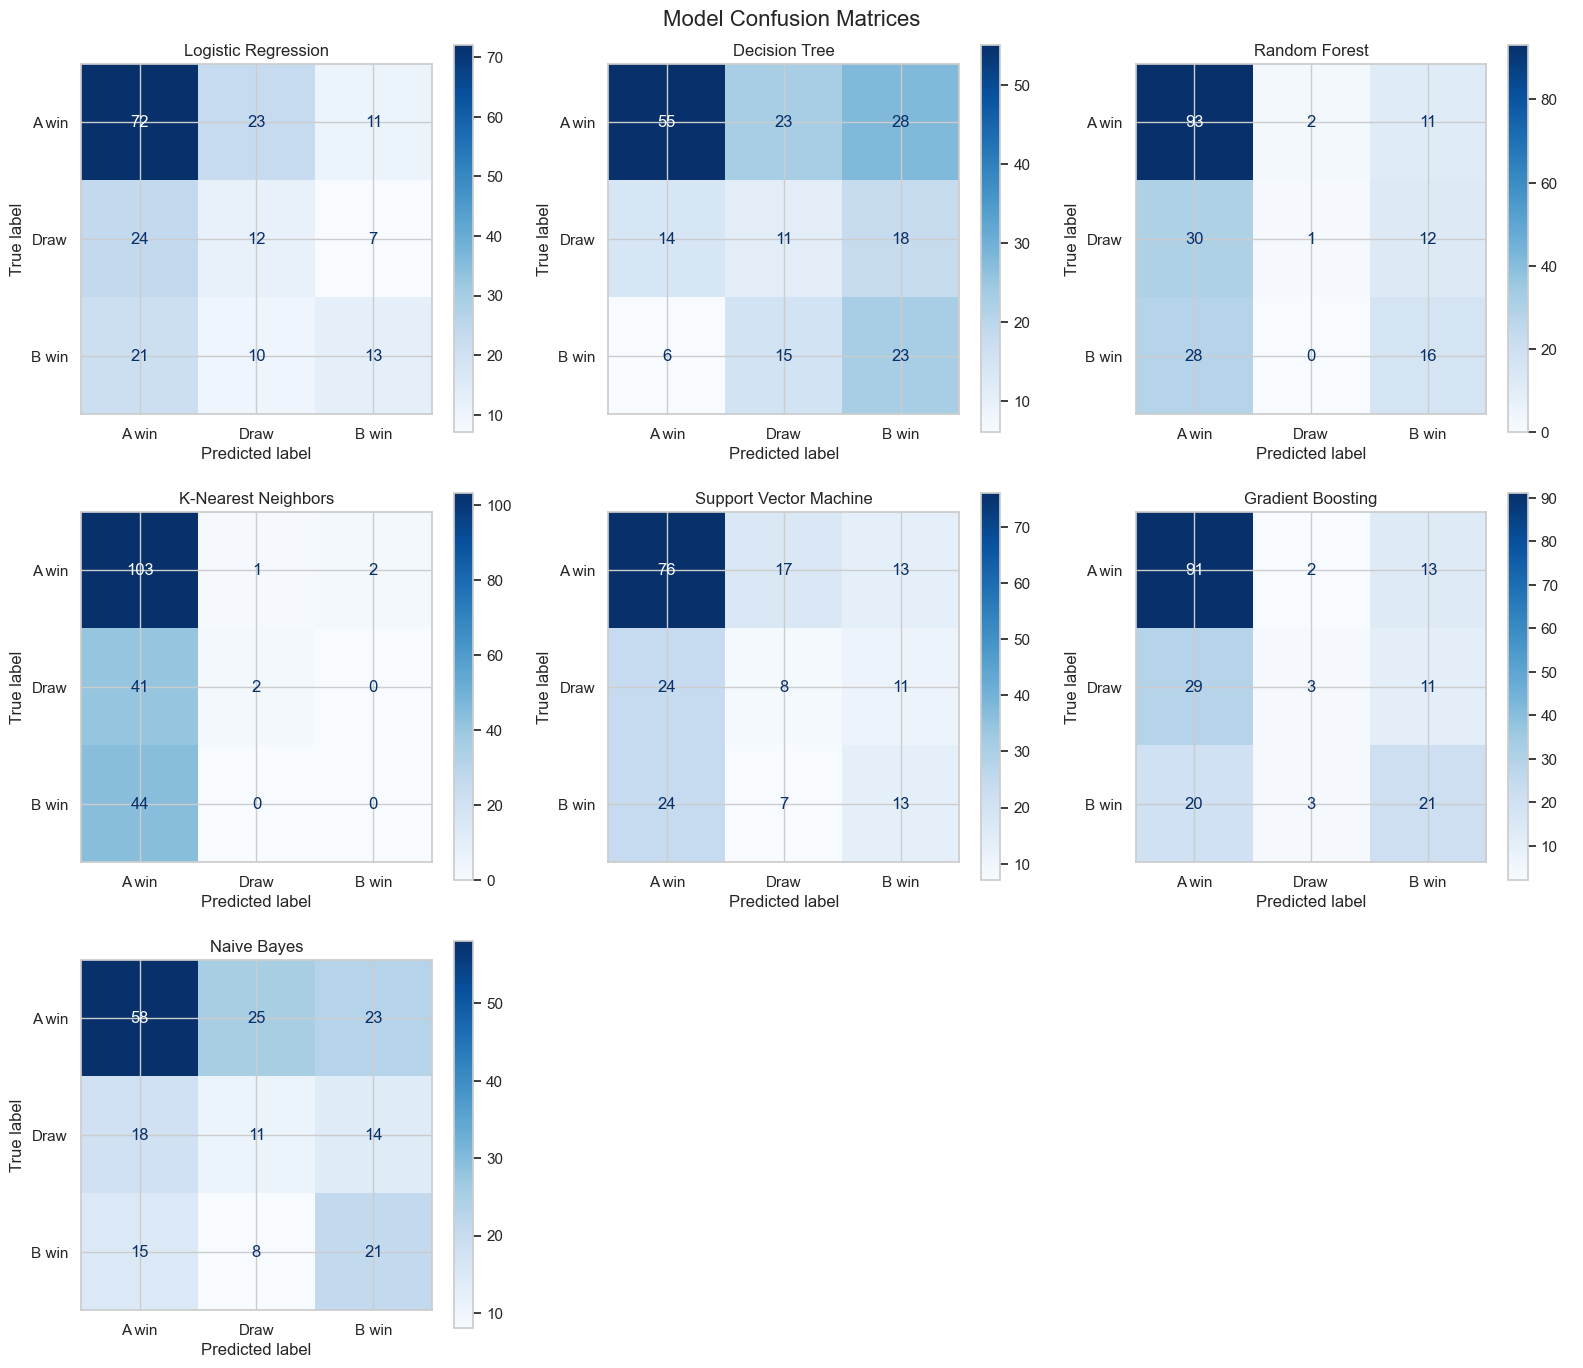

Majority-class baseline accuracy: 0.5492

Per-class test-set counts:
target
Team A win    106
Draw           43
Team B win     44
Name: count, dtype: int64

Best model by macro F1 (treats all outcomes equally):


,Macro Precision,Macro Recall,Macro F1
Model,,,
Gradient Boosting,0.4972,0.4685,0.4431
Logistic Regression,0.4338,0.4179,0.4217
Decision Tree,0.4304,0.4325,0.4180
Naive Bayes,0.4165,0.4268,0.4178
Support Vector Machine,0.4048,0.3995,0.3984
Random Forest,0.4532,0.4214,0.3843
K-Nearest Neighbors,0.4048,0.3394,0.2625


In [ ]:
# Confusion matrices and error diagnostics
from sklearn.metrics import ConfusionMatrixDisplay

trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Gradient Boosting": gradient_boosting_model,
    "Naive Bayes": naive_bayes_model
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()
for axis, (model_name, model) in zip(axes, trained_models.items()):
    predictions = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, display_labels=["A win", "Draw", "B win"],
        cmap="Blues", values_format="d", ax=axis
    )
    axis.set_title(model_name)
for axis in axes[len(trained_models):]:
    axis.axis("off")
plt.suptitle("Model Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

# Compare against a majority-class baseline and inspect class-level performance.
majority_class = y_train.mode()[0]
baseline_predictions = [majority_class] * len(y_test)
print(f"Majority-class baseline accuracy: {accuracy_score(y_test, baseline_predictions):.4f}")
print("\nPer-class test-set counts:")
print(y_test.map(target_names).value_counts().reindex(target_names.values()))
print("\nBest model by macro F1 (treats all outcomes equally):")
macro_scores = []
for model_name, model in trained_models.items():
    predictions = model.predict(X_test)
    macro_scores.append({
        "Model": model_name,
        "Macro Precision": precision_score(y_test, predictions, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, predictions, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, predictions, average="macro", zero_division=0)
    })
pd.DataFrame(macro_scores).sort_values("Macro F1", ascending=False).set_index("Model").round(4)



Calibrated Logistic Regression
[[23  0  6]
 [12  0  3]
 [18  0  2]]

Calibrated Gradient Boosting
[[26  0  3]
 [13  0  2]
 [17  0  3]]
Train rows: 900, test rows: 64


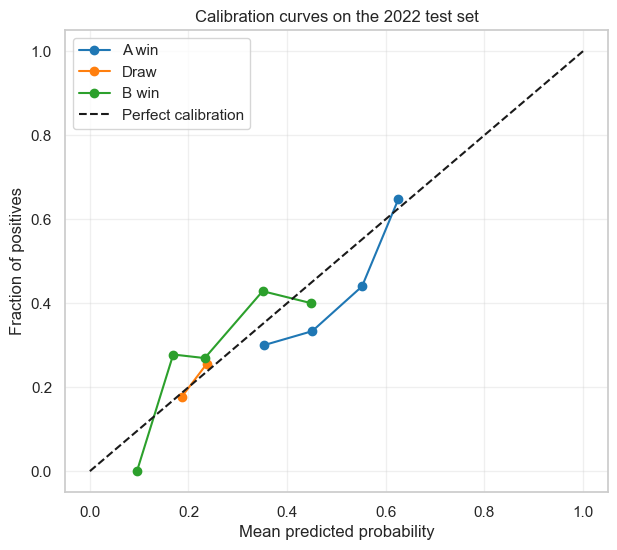

In [ ]:
# Improved pipeline: compact strength features, chronological Elo, calibration, and simulation
# TODO: Add FIFA rank/points features only after obtaining a local, non-downloaded source.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, log_loss,
                             brier_score_loss, confusion_matrix)
from sklearn.model_selection import StratifiedKFold

# Work from chronological data. Elo is always recorded before the current match.
strength_df = df.copy()
# Rating_wc-derived columns may be absent when using an older processed CSV.
# Keep the pipeline runnable; newly cleaned data will use the real historical values.
rating_columns = [
    'A_post_wc_rating', 'B_post_wc_rating', 'post_wc_rating_diff',
    'A_rating_available', 'B_rating_available'
]
for column_name in rating_columns:
    if column_name not in strength_df.columns:
        strength_df[column_name] = 0.0
strength_df["Date"] = pd.to_datetime(strength_df["Date"], errors="coerce")
strength_df = strength_df.sort_values("Date").reset_index(drop=True)
ratings = {}
elo_rows = []
team_snapshots = {}
initial_elo = 1500.0
k_factor = 20.0

for _, row in strength_df.iterrows():
    team_a, team_b = row["team_A"], row["team_B"]
    elo_a = ratings.get(team_a, initial_elo)
    elo_b = ratings.get(team_b, initial_elo)
    expected_a = 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

    elo_rows.append({
        "elo_A": elo_a, "elo_B": elo_b,
        "elo_diff": elo_a - elo_b,
        "expected_A": expected_a
    })


    actual_a = 1.0 if row["target"] == 0 else 0.5 if row["target"] == 1 else 0.0
    ratings[team_a] = elo_a + k_factor * (actual_a - expected_a)
    ratings[team_b] = elo_b + k_factor * ((1 - actual_a) - (1 - expected_a))

    # Save post-match Elo snapshots for cross-era simulations.
    for team, side in [(team_a, "A"), (team_b, "B")]:
        if team not in team_snapshots:
            team_snapshots[team] = []
        team_snapshots[team].append({
            "date": row["Date"], "year": int(row["Year"]),
            "elo": ratings[team],
            "goals_scored_last_5": row[f"{side}_goals_scored_last_5"],
            "goals_conceded_last_5": row[f"{side}_goals_conceded_last_5"],
            "win_rate_last_5": row[f"{side}_win_rate_last_5"],
            "matches_played_total": row[f"{side}_matches_played_total"], "post_wc_rating": row[f"{side}_post_wc_rating"], "rating_available": row[f"{side}_rating_available"]
        })

elo_df = pd.DataFrame(elo_rows)
strength_df = pd.concat([strength_df, elo_df], axis=1)

# Use relative strengths instead of sparse team, venue, manager, and calendar dummies.
compact_X = pd.DataFrame(index=strength_df.index)
compact_X["elo_diff"] = strength_df["elo_diff"]
compact_X["expected_A"] = strength_df["expected_A"]
compact_X["win_rate_diff"] = strength_df["A_win_rate_last_5"] - strength_df["B_win_rate_last_5"]
compact_X["goals_scored_diff"] = strength_df["A_goals_scored_last_5"] - strength_df["B_goals_scored_last_5"]
compact_X["goals_conceded_diff"] = strength_df["B_goals_conceded_last_5"] - strength_df["A_goals_conceded_last_5"]
compact_X["A_win_rate_last_5"] = strength_df["A_win_rate_last_5"]
compact_X["B_win_rate_last_5"] = strength_df["B_win_rate_last_5"]
compact_X["is_host_A"] = strength_df["is_host_A"]
compact_X["is_host_B"] = strength_df["is_host_B"]
compact_X["A_wc_rating"] = strength_df["A_post_wc_rating"].fillna(0)
compact_X["B_wc_rating"] = strength_df["B_post_wc_rating"].fillna(0)
compact_X["post_wc_rating_diff"] = strength_df["post_wc_rating_diff"].fillna(0)
compact_X["playoff_rating_available"] = strength_df["A_rating_available"] + strength_df["B_rating_available"]
compact_y = strength_df["target"].astype(int)

# Chronological evaluation: train before 2022, test on 2022.
train_mask = strength_df["Year"] < 2022
test_mask = strength_df["Year"] == 2022
X_strength_train = compact_X.loc[train_mask]
X_strength_test = compact_X.loc[test_mask]
y_strength_train = compact_y.loc[train_mask]
y_strength_test = compact_y.loc[test_mask]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
candidate_models = {
    "Calibrated Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, C=0.1))
    ]),
    "Calibrated Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.04, max_leaf_nodes=15,
        l2_regularization=2.0, random_state=42
    )
}

improved_results = []
improved_models = {}
for model_name, base_model in candidate_models.items():
    calibrated = CalibratedClassifierCV(base_model, method="sigmoid", cv=cv)
    calibrated.fit(X_strength_train, y_strength_train)
    probabilities = calibrated.predict_proba(X_strength_test)
    predictions = calibrated.predict(X_strength_test)
    improved_models[model_name] = calibrated
    improved_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_strength_test, predictions),
        "Macro F1": f1_score(y_strength_test, predictions, average="macro"),
        "LogLoss": log_loss(y_strength_test, probabilities),
        "Brier A": brier_score_loss((y_strength_test == 0).astype(int), probabilities[:, 0]),
        "Brier Draw": brier_score_loss((y_strength_test == 1).astype(int), probabilities[:, 1]),
        "Brier B": brier_score_loss((y_strength_test == 2).astype(int), probabilities[:, 2])
    })
    print(f"\n{model_name}")
    print(confusion_matrix(y_strength_test, predictions, labels=[0, 1, 2]))

improved_comparison = pd.DataFrame(improved_results).set_index("Model")
print(f"Train rows: {len(X_strength_train)}, test rows: {len(X_strength_test)}")
improved_comparison.round(4)

from sklearn.calibration import calibration_curve
plt.figure(figsize=(7, 6))
for class_id, label, color in [(0, "A win", "tab:blue"), (1, "Draw", "tab:orange"), (2, "B win", "tab:green")]:
    observed, predicted = calibration_curve((y_strength_test == class_id).astype(int), probabilities[:, class_id], n_bins=10, strategy="uniform")
    plt.plot(predicted, observed, marker="o", label=label, color=color)
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives")
plt.title("Calibration curves on the 2022 test set"); plt.legend(); plt.grid(alpha=0.3); plt.show()


In [ ]:
# Simulate a hypothetical matchup using the calibrated strength model.
def _snapshot_at_year(team, year):
    snapshots = [item for item in team_snapshots.get(team, []) if item["year"] <= year]
    if not snapshots:
        return {"elo": initial_elo, "goals_scored_last_5": 0,
                "goals_conceded_last_5": 0, "win_rate_last_5": 0,
                "matches_played_total": 0, "post_wc_rating": 0, "rating_available": 0}
    return snapshots[-1]

def simulate_match(team_a, team_a_year, team_b, team_b_year,
                   model_name="Calibrated Gradient Boosting",
                   team_a_is_host=False, team_b_is_host=False):
    a = _snapshot_at_year(team_a, team_a_year)
    b = _snapshot_at_year(team_b, team_b_year)
    features = pd.DataFrame([{
        "elo_diff": a["elo"] - b["elo"],
        "expected_A": 1 / (1 + 10 ** ((b["elo"] - a["elo"]) / 400)),
        "win_rate_diff": a["win_rate_last_5"] - b["win_rate_last_5"],
        "goals_scored_diff": a["goals_scored_last_5"] - b["goals_scored_last_5"],
        "goals_conceded_diff": b["goals_conceded_last_5"] - a["goals_conceded_last_5"],
        "A_win_rate_last_5": a["win_rate_last_5"],
        "B_win_rate_last_5": b["win_rate_last_5"],
        "is_host_A": int(team_a_is_host),
        "is_host_B": int(team_b_is_host), "A_wc_rating": a["post_wc_rating"], "B_wc_rating": b["post_wc_rating"], "post_wc_rating_diff": a["post_wc_rating"] - b["post_wc_rating"], "playoff_rating_available": int(a["rating_available"] + b["rating_available"])
    }], columns=compact_X.columns)
    model = improved_models[model_name]
    probabilities = model.predict_proba(features)[0]
    assert abs(float(probabilities.sum()) - 1.0) <= 1e-6, "Predicted probabilities must sum to 1"
    labels = {0: "Team A win", 1: "Draw", 2: "Team B win"}
    return {
        "team_a_win_probability": probabilities[0],
        "draw_probability": probabilities[1],
        "team_b_win_probability": probabilities[2],
        "predicted_outcome": labels[int(np.argmax(probabilities))]
    }

# Example:
# simulate_match("Argentina", 2022, "Brazil", 2002)


In [ ]:
# Walk-forward evaluation across World Cup tournaments.
# Each tournament is tested only with matches from earlier tournaments.
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

walk_forward = []
test_years = sorted(y for y in strength_df['Year'].unique() if y >= 1998)
for test_year in test_years:
    train_mask = strength_df['Year'] < test_year
    test_mask = strength_df['Year'] == test_year
    if train_mask.sum() == 0 or test_mask.sum() == 0 or compact_y.loc[train_mask].nunique() < 3:
        continue
    model = CalibratedClassifierCV(
        HistGradientBoostingClassifier(max_iter=200, learning_rate=0.04, max_leaf_nodes=15, random_state=42),
        method='sigmoid', cv=StratifiedKFold(5, shuffle=True, random_state=42)
    )
    model.fit(compact_X.loc[train_mask], compact_y.loc[train_mask])
    probabilities = model.predict_proba(compact_X.loc[test_mask])
    predictions = model.predict(compact_X.loc[test_mask])
    walk_forward.append({
        'Test year': test_year, 'Test matches': int(test_mask.sum()),
        'Accuracy': accuracy_score(compact_y.loc[test_mask], predictions),
        'Macro F1': f1_score(compact_y.loc[test_mask], predictions, average='macro'),
        'Log loss': log_loss(compact_y.loc[test_mask], probabilities, labels=[0, 1, 2])
    })
walk_forward_results = pd.DataFrame(walk_forward).set_index('Test year')
display(walk_forward_results.round(4))
print('Mean chronological accuracy:', round(walk_forward_results['Accuracy'].mean(), 4))
print('Mean chronological macro F1:', round(walk_forward_results['Macro F1'].mean(), 4))
print('Mean chronological log loss:', round(walk_forward_results['Log loss'].mean(), 4))


,Test matches,Accuracy,Macro F1,Log loss
Test year,,,,
1998,64,0.4375,0.2029,1.1464
2002,64,0.4219,0.1978,1.1429
2006,64,0.5156,0.2616,1.0229
2010,64,0.3594,0.1762,1.1613
2014,64,0.4375,0.2029,1.0931
2018,64,0.4062,0.1926,1.1022
2022,64,0.4531,0.2762,1.0555


Mean chronological accuracy: 0.433
Mean chronological macro F1: 0.2157
Mean chronological log loss: 1.1035


In [ ]:
# Export the already-trained best model for the GUI.
# Run this cell after all previous model-building cells.
from pathlib import Path
import pickle

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
model_path = project_root / 'model.pkl'
best_model = improved_models['Calibrated Gradient Boosting']
artifact = {
    'model': best_model,
    'snapshots': team_snapshots,
    'features': list(compact_X.columns),
    'labels': {0: 'Team A win', 1: 'Draw', 2: 'Team B win'},
    'trained_before_year': 2022,
}
with model_path.open('wb') as file:
    pickle.dump(artifact, file, protocol=pickle.HIGHEST_PROTOCOL)
print(f'Saved reusable model to: {model_path}')


Saved reusable model to: c:\Users\Chingiz\Documents\WC_DS_project\model.pkl
